# Basis Addition Use Case (Operator + Encode Enrichments)

This notebook compiles an enrichment-driven model (basis encoders + operator adder), runs the generated OpenQASM with Qiskit Aer, and checks that the dominant measured result corresponds to `1 + 3 = 4`.


## Workflow

1. Load `basis_addition_operator_enriched_1plus3.json`.
2. Send it to `POST /debug/compile`.
3. Execute generated OpenQASM with Qiskit Aer.
4. Inspect dominant output bitstring and decode candidates.


In [4]:
import json
from pathlib import Path

import requests
from IPython.display import display
from qiskit import qasm3, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [5]:
BASE_URL = "http://localhost:8000"
COMPILE_URL = f"{BASE_URL}/debug/compile"

USE_CASE_DIR = Path.cwd()
if not (USE_CASE_DIR / "basis_addition_operator_enriched_1plus3.json").exists():
    USE_CASE_DIR = Path("scripts/paper-results/06-basis-addition-enriched")

MODEL_PATH = USE_CASE_DIR / "basis_addition_operator_enriched_1plus3.json"
model_payload = json.loads(MODEL_PATH.read_text(encoding="utf-8"))
model_payload["metadata"]

{'version': '1.0.0',
 'name': 'Basis addition via enrichments (1 + 3)',
 'description': "Adds 1 and 3 using basis-encoding enrichment and the operator '+' enrichment, then measures the 3-bit sum register.",
 'author': 'paper-results'}

In [6]:
def compile_model(payload: dict) -> str:
    response = requests.post(COMPILE_URL, json=payload, timeout=120)
    response.raise_for_status()

    content_type = response.headers.get("content-type", "")
    if "application/json" in content_type:
        raise RuntimeError(f"Unexpected JSON response: {response.json()}")

    return response.text


qasm_text = compile_model(model_payload)
print("Compiled OpenQASM lines:", len(qasm_text.splitlines()))
print("\n".join(qasm_text.splitlines()[:60]))

Compiled OpenQASM lines: 45
OPENQASM 3.1;
include "stdgates.inc";
/* Qiskit compatibility warning: literal outputs from literal_a, literal_b feed other nodes; resulting circuit may be incompatible. */
qubit[8] leqo_reg;
/* Start node encode_a */
let leqo_272309899a4258c5a609df53796a99aa_encoded = leqo_reg[{0, 1}];
x leqo_272309899a4258c5a609df53796a99aa_encoded[0];
@leqo.output 0
let leqo_272309899a4258c5a609df53796a99aa_out = leqo_272309899a4258c5a609df53796a99aa_encoded;
/* End node encode_a */
/* Start node encode_b */
let leqo_ca3bca418dee501f8e30173d98dcbe33_encoded = leqo_reg[{2, 3}];
x leqo_ca3bca418dee501f8e30173d98dcbe33_encoded[0];
x leqo_ca3bca418dee501f8e30173d98dcbe33_encoded[1];
@leqo.output 0
let leqo_ca3bca418dee501f8e30173d98dcbe33_out = leqo_ca3bca418dee501f8e30173d98dcbe33_encoded;
/* End node encode_b */
/* Start node adder */
@leqo.input 0
let leqo_a009c0055fa25b609f5bd99dc5243a5b_addend0 = leqo_reg[{0, 1}];
@leqo.input 1
let leqo_a009c0055fa25b609f5bd99dc5243a5b_a

Counts: {'100 ': 1024}


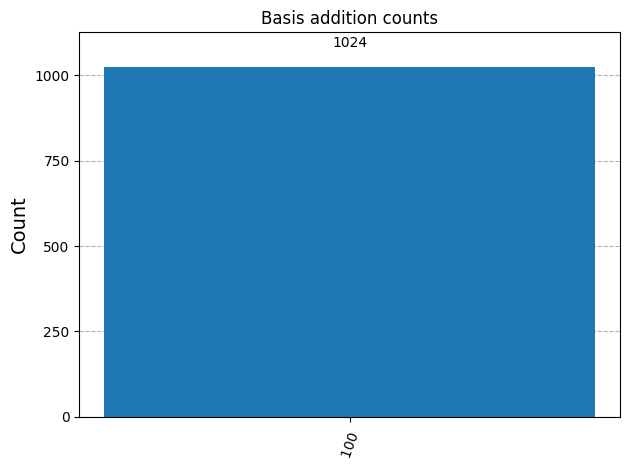

In [7]:
qc = qasm3.loads(qasm_text)

simulator = AerSimulator()
compiled = transpile(qc, simulator)
shots = 1024
counts = simulator.run(compiled, shots=shots).result().get_counts()

print("Counts:", counts)
display(plot_histogram(counts, title="Basis addition counts"))

In [8]:
dominant = max(counts, key=counts.get).replace(" ", "")
msb_decode = int(dominant, 2)
lsb_decode = int(dominant[::-1], 2)

print(f"Dominant bitstring: {dominant}")
print(f"MSB-first decode: {msb_decode}")
print(f"LSB-first decode: {lsb_decode}")

if 4 in {msb_decode, lsb_decode}:
    print("Decoded sum matches expected value 4.")
else:
    print("Decoded sum did not match 4. Check backend output ordering.")

Dominant bitstring: 100
MSB-first decode: 4
LSB-first decode: 1
Decoded sum matches expected value 4.
